In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

In [2]:
data =  "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

urlretrieve(data, "car_fuel_efficiency_2026.csv.csv")

('car_fuel_efficiency_2026.csv.csv',
 <http.client.HTTPMessage at 0x2501734b830>)

In [73]:
df = pd.read_csv('car_fuel_efficiency_2026.csv.csv')

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [74]:
df_usable = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']].copy()

df_usable

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [75]:
df_usable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


### EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

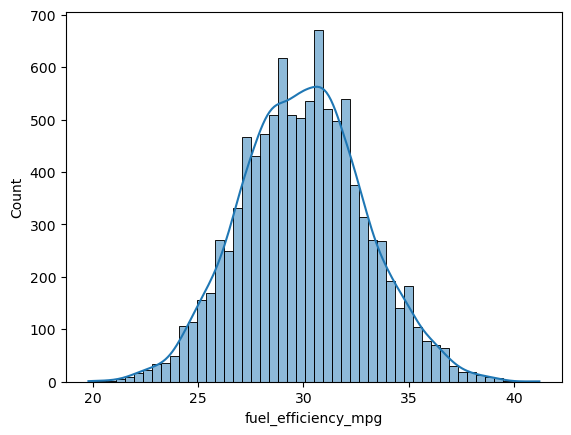

In [76]:
sns.histplot(df_usable.fuel_efficiency_mpg , bins= 50, kde=True)

- What's the median (50% percentile) for variable 'horsepower'?

In [77]:
df_usable.horsepower.median()

254.0

### Prepare and split the dataset

In [78]:
n  = len(df_usable)
n_val = int(n *0.2)
n_test = int(n *0.2)
n_train = n - n_val - n_test

n, n_val, n_test, n_train

(10000, 2000, 2000, 6000)

In [79]:
# Shuffling

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_usable.iloc[idx[:n_train]]
df_val = df_usable.iloc[idx[n_train: n_train + n_val]]
df_test = df_usable.iloc[idx[n_train + n_val:]]
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7


In [80]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [81]:
# Splitting X and y
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

y_train.head()

0    32.5
1    29.1
2    34.1
3    30.6
4    30.7
Name: fuel_efficiency_mpg, dtype: float64

In [82]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [83]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


### Fill NaN and Train

- with Zero

In [84]:
def prepare_X (df):
    df_num = df.fillna(0)
    return df_num.values

In [85]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [86]:
def rmse(y, y_pred):
    error = y-y_pred
    mse = np.mean(error **2)
    return np.sqrt(mse)

#### Train

In [87]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

X_train[:5]

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       [2300.,    0., 4150., 1997.],
       [2340.,  269., 4400., 2001.]])

In [88]:
w0, w = train_linear_regression(X_train, y_train)

In [89]:
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

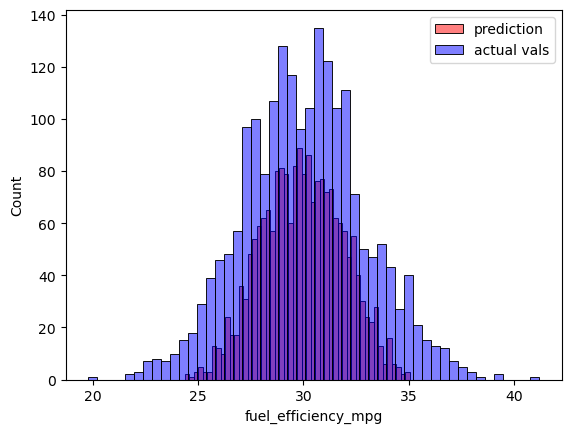

In [90]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_val, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

- With Mean

In [91]:
mean = df_train.horsepower.mean()
mean

np.float64(254.46338337605272)

In [92]:
def prepare_X_mean (df):
    df_ = df.copy()
    df_.horsepower = df_.horsepower.fillna(mean)
    return df_.values

In [93]:
X_train = prepare_X_mean(df_train)
X_val = prepare_X_mean(df_val)

X_train[:5]

array([[1900.        ,  239.        , 3790.        , 2015.        ],
       [2000.        ,  224.        , 4380.        , 1992.        ],
       [2330.        ,  286.        , 4090.        , 2022.        ],
       [2300.        ,  254.46338338, 4150.        , 1997.        ],
       [2340.        ,  269.        , 4400.        , 2001.        ]])

In [94]:
w0, w = train_linear_regression(X_train, y_train)

In [95]:
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

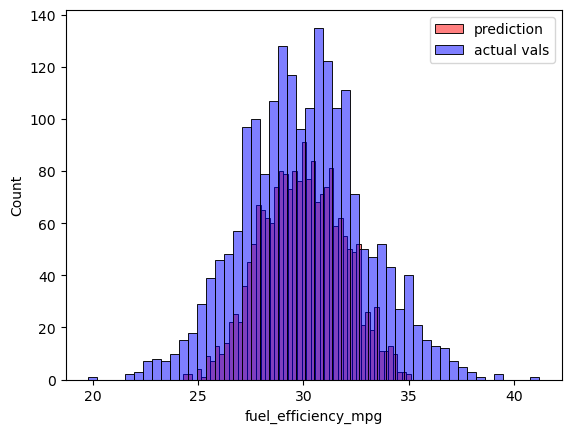

In [96]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_val, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

### Regularised  Model

In [97]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [98]:
params = np.empty((0, 3))
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)

    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val =prepare_X(df_val)

    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)

    params = np.vstack([params,[r, w0, score]])

In [99]:
params

array([[ 0.00000000e+00, -1.53884962e+02,  2.20530000e+00],
       [ 1.00000000e-02, -1.48309212e+02,  2.20580000e+00],
       [ 1.00000000e-01, -1.11838710e+02,  2.22410000e+00],
       [ 1.00000000e+00, -3.23318660e+01,  2.34920000e+00],
       [ 5.00000000e+00, -7.77285221e+00,  2.40940000e+00],
       [ 1.00000000e+01, -3.98711642e+00,  2.41950000e+00],
       [ 1.00000000e+02, -4.08219649e-01,  2.42920000e+00]])

c:\Users\Samuel\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\Samuel\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\Samuel\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


Text(0, 0.5, 'regularization')

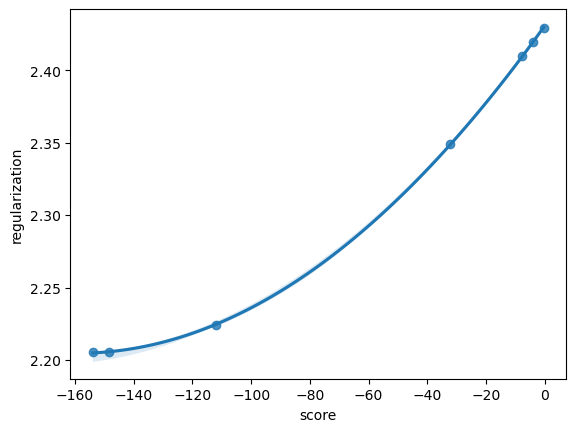

In [100]:
sns.regplot(x=params[:, 1], y=params[:, 2], order=2)
plt.xlabel("score")
plt.ylabel("regularization")

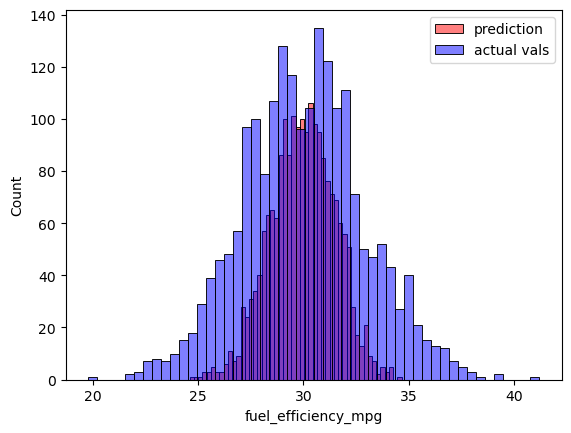

In [101]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_val, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

### Trying Different Seeds

In [115]:

# Shuffling
scores = np.array([])
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_usable.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df_usable.iloc[idx[n_train: n_train + n_val]].reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    X_val = prepare_X(df_val)
    
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val =prepare_X(df_val)
    
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    scores = np.append(scores, score)
scores

array([2.23920414, 2.20211282, 2.16341978, 2.20435888, 2.20188009,
       2.24578515, 2.26972121, 2.1907946 , 2.2166112 , 2.20703659])

In [116]:
round(np.std(scores), 3)

np.float64(0.029)

### Testing

In [155]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_usable.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df_usable.iloc[idx[n_train: n_train + n_val]].reset_index(drop=True)
df_test = df_usable.iloc[idx[n_train + n_val: ]].reset_index(drop=True)


In [156]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,2320,246.0,4100,2014
1,2230,252.0,4250,1998
2,2700,276.0,4490,2008
3,2220,269.0,4060,2004
4,2370,NaN,4690,1979
...,...,...,...,...
5995,1950,231.0,4150,1989
5996,2060,249.0,3910,2012
5997,2180,223.0,4360,2014
5998,2420,248.0,4080,1977


In [157]:
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train)

df_full_train.shape

(8000, 4)

In [158]:


w0, w = train_linear_regression(X_full_train, y_full_train)
    
X_test =prepare_X(df_test)
    
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

score

np.float64(2.2357747027980595)